In [17]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, RocCurveDisplay,confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import joblib

In [3]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 7.3 MB/s eta 0:00:00a 0:00:01

[notice] A new release of pip is available: 25.0.1 -> 25.2
[notice] To update, run: pip3.11 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [5]:
data = pd.read_csv('telco.csv')


In [6]:
data['Churn'] = data['Churn'].map({'Yes':1, 'No':0})

In [7]:
data['TotalCharges'] = pd.to_numeric(data['TotalCharges'],errors='coerce').fillna(0)

In [8]:
#Define feature
X = data.drop(['Churn','customerID'], axis=1)
y = data['Churn']

In [9]:
#Split data
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

In [13]:
#Define categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns

In [14]:
#Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore'), categorical_cols)
    ])

In [15]:
models = {
    'Logistic Regression': LogisticRegression(C=1.0, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'XGBoost': XGBClassifier(random_state=42, scale_pos_weight=len(y_train[y_train == 0]) / len(y_train[y_train == 1]))
}


Results for Logistic Regression:
Accuracy: 0.7501774308019872
Classification Report:
               precision    recall  f1-score   support

           0       0.92      0.72      0.81      1036
           1       0.52      0.83      0.64       373

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409

ROC-AUC: 0.8621412009481716


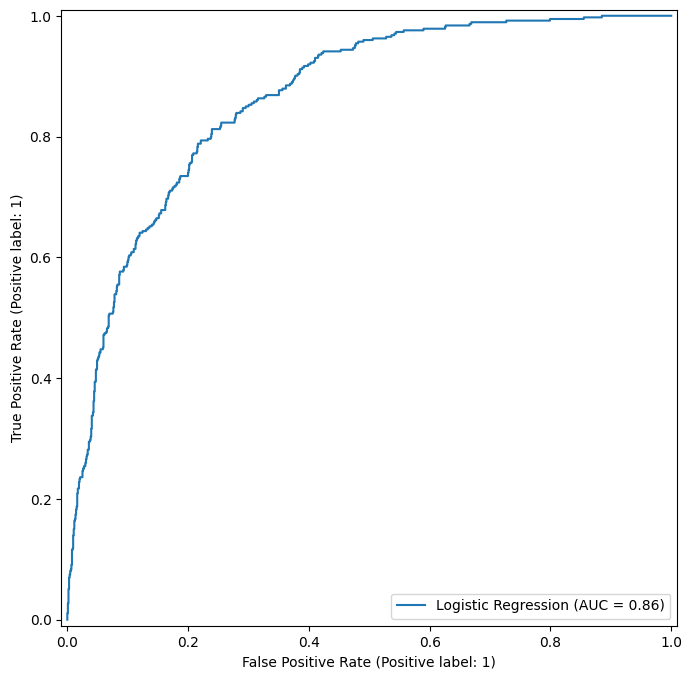

<Figure size 500x400 with 0 Axes>

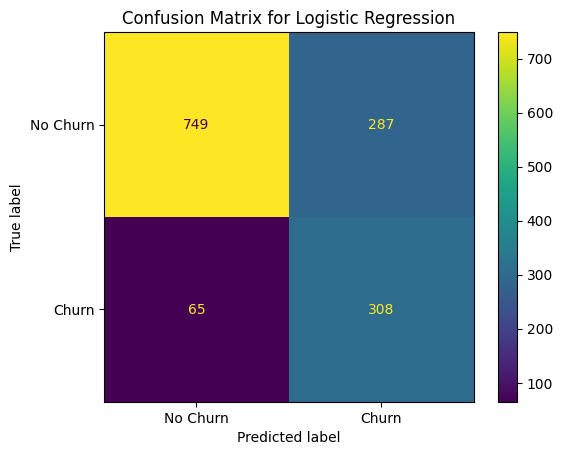


Results for Random Forest:
Accuracy: 0.7906316536550745
Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.92      0.87      1036
           1       0.65      0.45      0.53       373

    accuracy                           0.79      1409
   macro avg       0.74      0.68      0.70      1409
weighted avg       0.78      0.79      0.78      1409

ROC-AUC: 0.835665376214974


<Figure size 500x400 with 0 Axes>

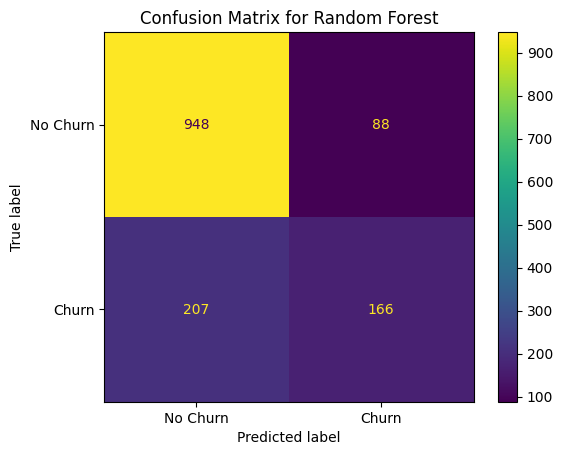


Results for XGBoost:
Accuracy: 0.7764371894960965
Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.81      0.84      1036
           1       0.56      0.70      0.62       373

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409

ROC-AUC: 0.8391614996842879


<Figure size 500x400 with 0 Axes>

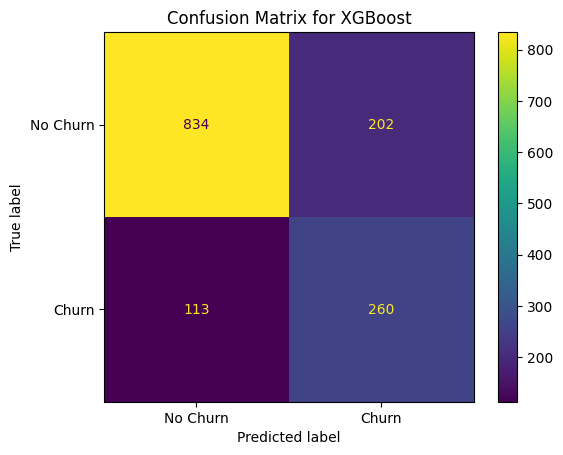

In [19]:
# Train and evaluate
fig, ax = plt.subplots(figsize=(10, 8))  # Create a single figure and axis
for name, model in models.items():
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])
    
    # Train
    pipeline.fit(X_train, y_train)
    
    # Evaluate
    y_pred = pipeline.predict(X_test)
    y_pred_proba = pipeline.predict_proba(X_test)[:, 1]
    
    print(f"\nResults for {name}:")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print("Classification Report:\n", classification_report(y_test, y_pred))
    print("ROC-AUC:", roc_auc_score(y_test, y_pred_proba))
    
    # Save pipeline
    joblib.dump(pipeline, f'{name.lower().replace(" ", "_")}_pipeline.pkl')
    
    # Plot ROC curve on the same axis
    RocCurveDisplay.from_estimator(pipeline, X_test, y_test, name=name, ax=ax)
    
    # Plot confusion matrix
    plt.figure(figsize=(5, 4))
    cm = confusion_matrix(y_test, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=["No Churn", "Churn"]).plot()
    plt.title(f"Confusion Matrix for {name}")
    plt.savefig(f"confusion_matrix_{name.lower().replace(' ', '_')}.png")
    plt.show()

# Finalize ROC plot
ax.set_title("ROC Curves for Churn Prediction Models")
fig.savefig("roc_comparison.png")
plt.close(fig)